In [21]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('california_housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200


In [6]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
ocean_proximity         0
median_house_value      0
dtype: int64

In [7]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['ocean_proximity'] = le.fit_transform(df['ocean_proximity'])

print("Missing values after fix:", df.isnull().sum().sum())
df.head()

Missing values after fix: 0


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,3,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,3,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,3,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,3,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,3,342200


In [11]:
from sklearn.model_selection import train_test_split
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (16512, 9)
Test size:  (4128, 9)


In [24]:
#Train gradient boost regressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
model = GradientBoostingRegressor(
    n_estimators=2000,
    learning_rate=0.2,
    max_depth=3
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred1 = model.predict(X_train)
print("r2_score for test: ",r2_score(y_test,y_pred))
print("r2_score for train: ",r2_score(y_train,y_pred1))




r2_score for test:  0.8165261316932171
r2_score for train:  0.9536937633165156


In [20]:
print(f"{'Loss':<15} {'R2':>8} {'MAE':>12} {'RMSE':>12}")
print("-" * 50)

for loss in ['squared_error', 'absolute_error', 'huber']:
    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        loss=loss,
        random_state=42
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    print(f"{loss:<15} {r2:>8.4f} {mae:>12,.0f} {rmse:>12,.0f}")

Loss                  R2          MAE         RMSE
--------------------------------------------------
squared_error     0.7585       38,645       56,256
absolute_error    0.7155       39,499       61,060
huber             0.7485       38,270       57,405


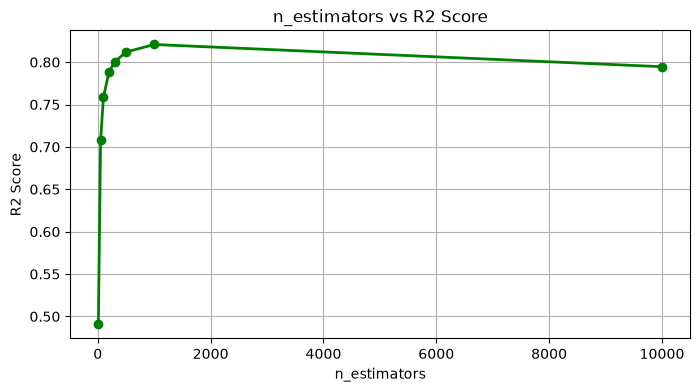

In [ ]:
estimator_range = [10, 50, 100, 200, 300, 500, 1000, 10000]
r2_scores = []

for n in estimator_range:
    model = GradientBoostingRegressor(
        n_estimators=n,
        learning_rate=0.1,
        random_state=42
    )
    model.fit(X_train, y_train)
    r2_scores.append(r2_score(y_test, model.predict(X_test)))

plt.figure(figsize=(8, 4))
plt.plot(estimator_range, r2_scores, marker='o', color='green', linewidth=2)
plt.xlabel('n_estimators')
plt.ylabel('R2 Score')
plt.title('n_estimators vs R2 Score')
plt.grid(True)
plt.show()